In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
# CHANGED: Use sklearn metrics directly
import sklearn.metrics as skm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions

paths = load_paths()
logger = setup_logger(level="INFO")

# 1. Load Artifacts from Balanced Bagging Run
# Instead of re-running the ensemble creation, we load the results from the training step (Notebook 10)
logger.info("Loading Balanced Bagging Artifacts...")

bagging_dir = paths.artifacts_dir / "balanced_bagging"
metrics_path = bagging_dir / "metrics.json"
preds_path = bagging_dir / "predictions.csv" # Changed from test_predictions.csv

if not metrics_path.exists() or not preds_path.exists():
    logger.error(f"Artifacts not found in {bagging_dir}. Please run Notebook 10 first.")
    raise FileNotFoundError("Balanced Bagging artifacts missing.")

with open(metrics_path, "r") as f:
    metrics = json.load(f)

df_preds = pd.read_csv(preds_path)

if "prob" not in df_preds.columns:
    raise ValueError("Missing calibrated probability column 'prob' in predictions.csv")
if "prob_raw" not in df_preds.columns:
    raise ValueError("Missing raw probability column 'prob_raw' in predictions.csv")

df_preds = df_preds.rename(columns={"prob": "p_calib"})

# Ensure split column exists (it should in predictions.csv)
if "split" not in df_preds.columns:
    logger.warning("'split' column missing in predictions.csv. Assuming 'test'.")
    df_preds["split"] = "test"

logger.info(f"Loaded metrics and {len(df_preds)} predictions.")


2026-03-07 03:11:23 | INFO | ai-vpn-firewall | Loading Balanced Bagging Artifacts...
2026-03-07 03:11:23 | INFO | ai-vpn-firewall | Loaded metrics and 19908 predictions.


In [2]:
print("\n" + "="*60)
print("ADVANCED FIREWALL EVALUATION (BALANCED BAGGING ENSEMBLE)")
print("="*60)

# Extract thresholds from metrics (they are stored in the 'val' section of the new metrics structure)
# The structure from train_balanced_bagging_ensemble.py is:
# results['val']['fpr_0.001']['threshold']
val_metrics = metrics.get("val", {})

# Helper to find threshold for a target FPR
def get_threshold_from_metrics(metrics_dict, target_fpr):
    key = f"fpr_{target_fpr}"
    if key in metrics_dict:
        return metrics_dict[key]["threshold"]
    # Fallback: try string formatting
    key_str = f"fpr_{str(target_fpr)}"
    if key_str in metrics_dict:
        return metrics_dict[key_str]["threshold"]
    return 0.99

T_BLOCK = get_threshold_from_metrics(val_metrics, 0.001)
T_MONITOR = get_threshold_from_metrics(val_metrics, 0.01)

print(f"Global Policy Thresholds (tuned on VAL):")
print(f"  - BLOCK:   p >= {T_BLOCK:.4f} (Target FPR: 0.1%)")
print(f"  - MONITOR: p >= {T_MONITOR:.4f} (Target FPR: 1%)")

# Flow-Level Evaluation on Test Data
print("\n--- [1] Flow-Level Triage Performance (on TEST set, CALIBRATED) ---")
test_preds = df_preds[df_preds["split"] == "test"].copy()
y_true = test_preds["label"].astype(int)
p_calib = test_preds["p_calib"]

for name, thr in [("BLOCK", T_BLOCK), ("MONITOR", T_MONITOR)]:
    y_hat = (p_calib >= thr).astype(int)
    prec, rec, _, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0, 1]).ravel()
    achieved_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f"\n{name} ZONE:")
    print(f"  Recall: {rec:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  False Positives: {fp}")
    print(f"  Achieved FPR: {achieved_fpr:.5f}")

# Session-Level
print("\n--- [2] Session-Level Aggregation Performance (on TEST set) ---")
if "capture_id" in test_preds.columns:
    session_df = test_preds.groupby("capture_id").agg(
    session_score=("p_calib", "max"),
    session_label=("label", "max")
).reset_index()

    y_true_sess = session_df["session_label"]
    p_sess = session_df["session_score"]
    y_hat_sess_block = (p_sess >= T_BLOCK).astype(int)
    prec_sess, rec_sess, _, _ = precision_recall_fscore_support(y_true_sess, y_hat_sess_block, average="binary", zero_division=0)
    tn_s, fp_s, fn_s, tp_s = confusion_matrix(
        y_true_sess, y_hat_sess_block, labels=[0, 1]
    ).ravel()

    print("\nSESSION BLOCK (max(p) >= T_BLOCK)")
    print(f"  - Recall:    {rec_sess:.4f}")
    print(f"  - Precision: {prec_sess:.4f}")
    print(f"  - False Positive Sessions: {fp_s} / {tn_s + fp_s}")
else:
    print("Skipping session-level eval (capture_id missing).")

# Voipbuster Case Study
print("\n--- [3] Voipbuster Case Study ---")
if "capture_id" in test_preds.columns and test_preds["capture_id"].astype(str).str.contains("voipbuster", na=False).any():
    vb_mask = test_preds["capture_id"].astype(str).str.contains("voipbuster", na=False)
    max_prob_vb = test_preds[vb_mask]["p_calib"].max()
    print(f"Voipbuster Max Flow Probability: {max_prob_vb:.4f}")
    if max_prob_vb >= T_BLOCK: print("  - RESULT: BLOCKED at the session level.")
    elif max_prob_vb >= T_MONITOR: print("  - RESULT: FLAGGED for monitoring.")
    else: print("  - RESULT: ALLOWED (missed).")
else:
    print("Voipbuster not found in the test set.")
print("\n" + "="*60)

# --- Per-Dataset Evaluation ---
print("\n--- Per-Dataset Evaluation (on TEST set) ---")

if "dataset" in test_preds.columns:
    test_vnat = test_preds[test_preds["dataset"] == "vnat"]
    test_iscx = test_preds[test_preds["dataset"] == "iscx"]

    for name, df_test in [("VNAT", test_vnat), ("ISCX", test_iscx)]:
        print(f"\n--- {name} TEST Performance ---")
        if df_test.empty:
            print("No test data.")
            continue

        y_true = df_test["label"].astype(int)
        y_true = df_test["label"].astype(int)
        p_calib = df_test["p_calib"]
        p_raw = df_test["prob_raw"]

        auc_raw = skm.roc_auc_score(y_true, p_raw)
        auc_cal = skm.roc_auc_score(y_true, p_calib)
        ap_raw = skm.average_precision_score(y_true, p_raw)
        ap_cal = skm.average_precision_score(y_true, p_calib)

        print(f"ROC AUC raw:   {auc_raw:.4f}")
        print(f"ROC AUC raw:   {auc_raw:.4f}")
        print(f"ROC AUC calib: {auc_cal:.4f}")
        print(f"PR AUC calib:  {ap_cal:.4f}")

        for zone, t in [("BLOCK", T_BLOCK), ("MONITOR", T_MONITOR)]:
            y_hat = (p_calib >= t).astype(int)
            prec, rec, _, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
            tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0, 1]).ravel()
            achieved_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            print(f"{zone} (p >= {t:.6f}): Recall={rec:.4f}, Precision={prec:.4f}, FPR={achieved_fpr:.5f} (FP={fp})")
else:
    print("WARNING: 'dataset' column missing. Skipping per-dataset evaluation.")

print("\n" + "="*60)



ADVANCED FIREWALL EVALUATION (BALANCED BAGGING ENSEMBLE)
Global Policy Thresholds (tuned on VAL):
  - BLOCK:   p >= 0.7292 (Target FPR: 0.1%)
  - MONITOR: p >= 0.6622 (Target FPR: 1%)

--- [1] Flow-Level Triage Performance (on TEST set, CALIBRATED) ---

BLOCK ZONE:
  Recall: 0.5259
  Precision: 0.9925
  False Positives: 1
  Achieved FPR: 0.00063

MONITOR ZONE:
  Recall: 0.6813
  Precision: 0.8028
  False Positives: 42
  Achieved FPR: 0.02637

--- [2] Session-Level Aggregation Performance (on TEST set) ---

SESSION BLOCK (max(p) >= T_BLOCK)
  - Recall:    0.7059
  - Precision: 0.9231
  - False Positive Sessions: 1 / 30

--- [3] Voipbuster Case Study ---
Voipbuster Max Flow Probability: 1.0000
  - RESULT: BLOCKED at the session level.


--- Per-Dataset Evaluation (on TEST set) ---

--- VNAT TEST Performance ---
ROC AUC raw:   0.9961
ROC AUC raw:   0.9961
ROC AUC calib: 0.9971
PR AUC calib:  0.9279
BLOCK (p >= 0.729182): Recall=0.6154, Precision=1.0000, FPR=0.00000 (FP=0)
MONITOR (p >= 0


--- Generating Plots for Ensemble (Calibrated) ---


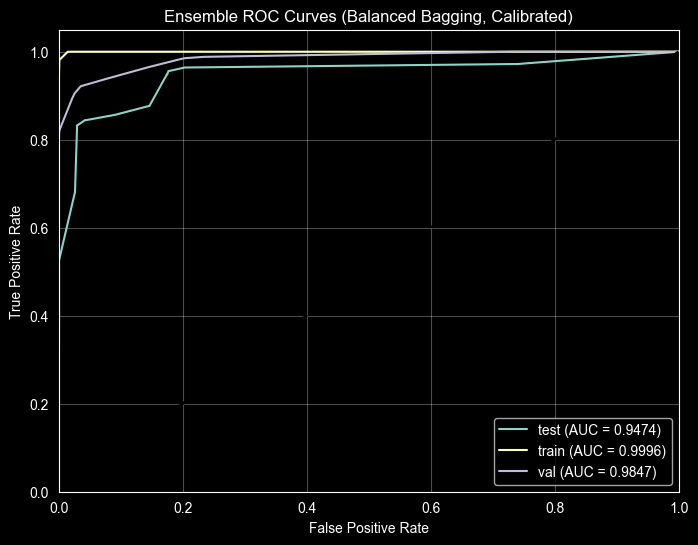

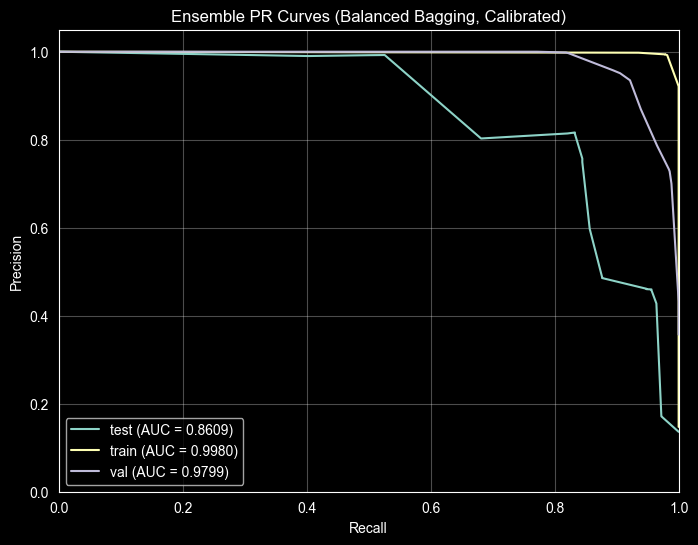

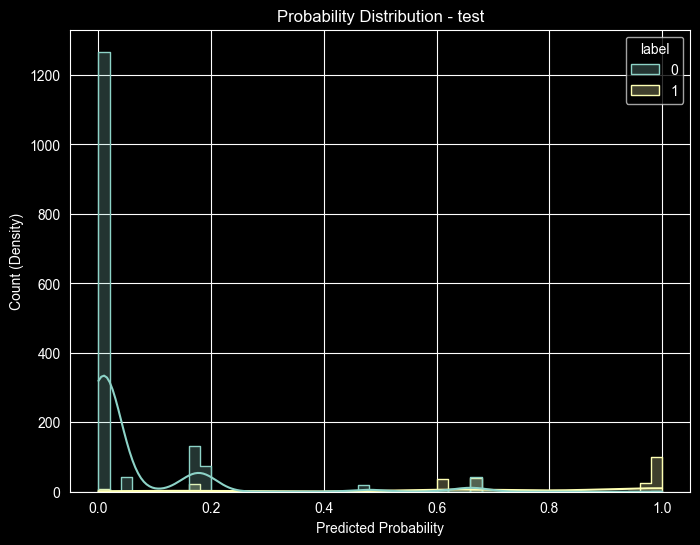

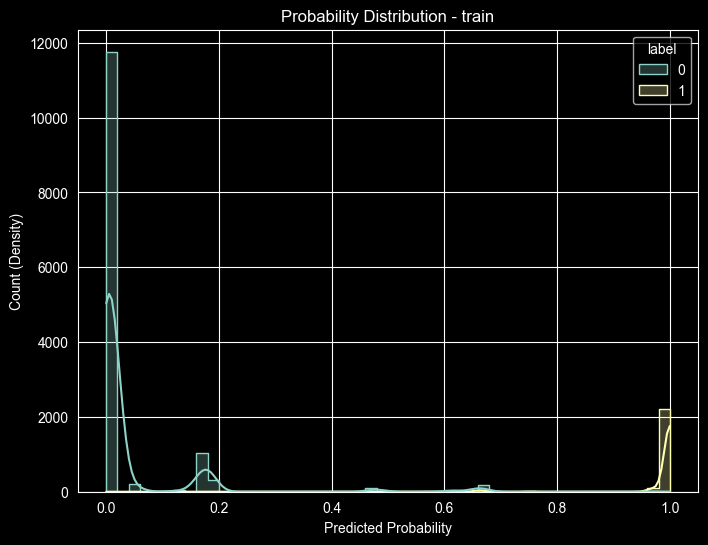

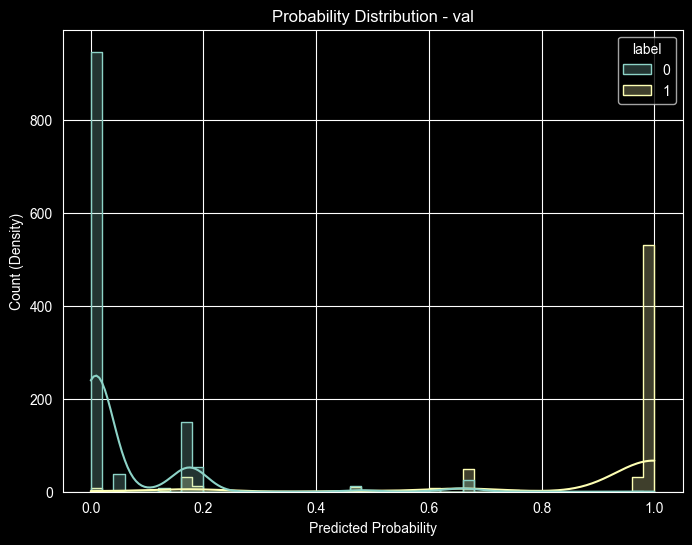

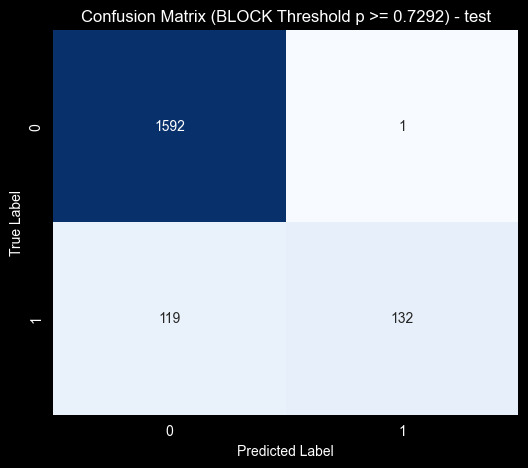

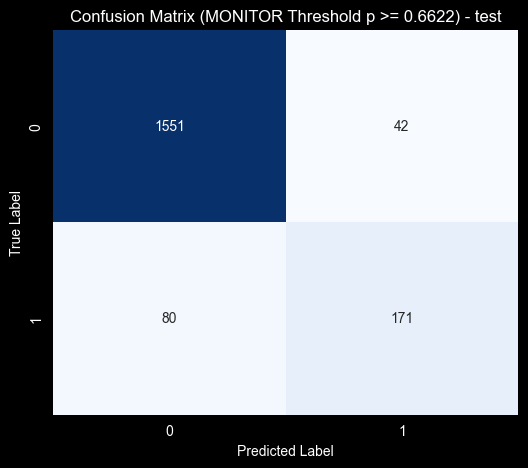

In [3]:
# 4. Visualization
print("\n--- Generating Plots for Ensemble (Calibrated) ---")
plot_roc_curves(df_preds, prob_col="p_calib", title="Ensemble ROC Curves (Balanced Bagging, Calibrated)")
plot_pr_curves(df_preds, prob_col="p_calib", title="Ensemble PR Curves (Balanced Bagging, Calibrated)")
plot_probability_distributions(df_preds, prob_col="p_calib")

test_preds = df_preds[df_preds["split"] == "test"].copy()
plot_confusion_matrices(
    test_preds,
    prob_col="p_calib",
    threshold=T_BLOCK,
    title=f"Confusion Matrix (BLOCK Threshold p >= {T_BLOCK:.4f})"
)
plot_confusion_matrices(
    test_preds,
    prob_col="p_calib",
    threshold=T_MONITOR,
    title=f"Confusion Matrix (MONITOR Threshold p >= {T_MONITOR:.4f})"
)

In [4]:
def plot_reliability_curve(y_true, y_prob, n_bins=10, title="Reliability Diagram"):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    pred_means = []
    obs_rates = []
    counts = []

    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        pred_means.append(y_prob[mask].mean())
        obs_rates.append(y_true[mask].mean())
        counts.append(mask.sum())

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.plot(pred_means, obs_rates, marker="o")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive rate")
    plt.title(title)
    plt.grid(True)
    plt.show()

    return pd.DataFrame({
        "bin_pred_mean": pred_means,
        "bin_obs_rate": obs_rates,
        "count": counts,
    })


--- VALIDATION RELIABILITY: RAW ---


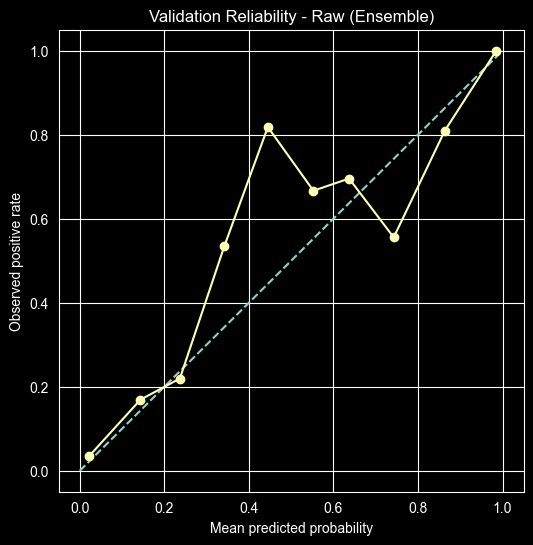

,bin_pred_mean,bin_obs_rate,count
0,0.021193,0.033884,1151
1,0.143587,0.169231,65
2,0.236732,0.219512,41
3,0.342271,0.535714,28
4,0.444918,0.818182,11
5,0.552678,0.666667,15
6,0.637012,0.695652,23
7,0.742615,0.555556,18
8,0.863453,0.809524,21
9,0.984103,0.998192,553



--- VALIDATION RELIABILITY: CALIBRATED ---


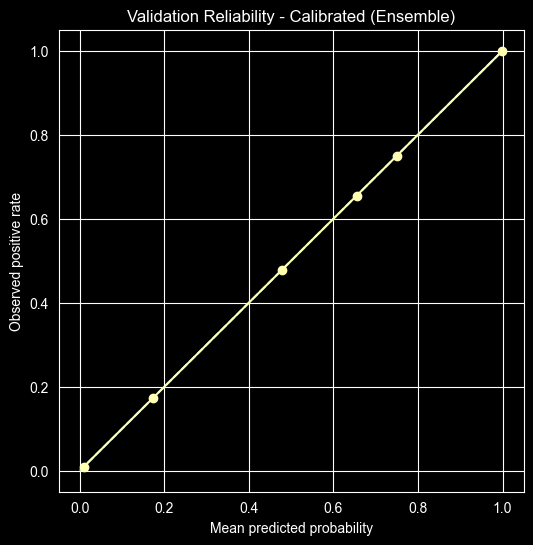

,bin_pred_mean,bin_obs_rate,count
0,0.010050,0.010050,995
1,0.173913,0.173913,253
2,0.478261,0.478261,23
3,0.655172,0.655172,87
4,0.750000,0.750000,4
5,0.998227,0.998227,564



--- TEST RELIABILITY: RAW ---


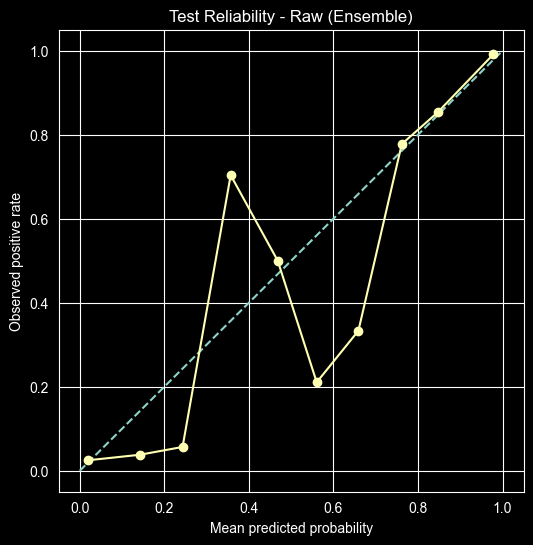

,bin_pred_mean,bin_obs_rate,count
0,0.019496,0.024896,1446
1,0.141950,0.037975,79
2,0.243133,0.056604,53
3,0.356955,0.703704,54
4,0.468237,0.500000,8
5,0.560421,0.210526,19
6,0.659098,0.333333,18
7,0.761723,0.777778,18
8,0.846256,0.852941,34
9,0.978236,0.991304,115



--- TEST RELIABILITY: CALIBRATED ---


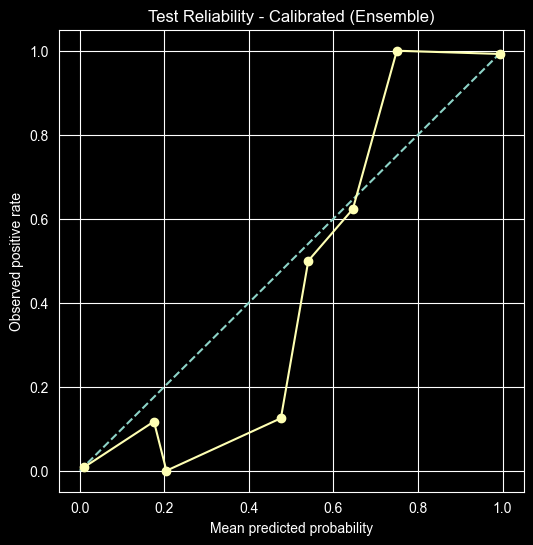

,bin_pred_mean,bin_obs_rate,count
0,0.010122,0.008321,1322
1,0.175417,0.117155,239
2,0.204924,0.000000,2
3,0.475726,0.125000,24
4,0.540612,0.500000,2
5,0.645943,0.622951,122
6,0.750000,1.000000,3
7,0.993183,0.992308,130


In [5]:
if "p_calib" not in df_preds.columns and "prob" in df_preds.columns:
    df_preds = df_preds.rename(columns={"prob": "p_calib"})

val_preds = df_preds[df_preds["split"] == "val"].copy()
test_preds = df_preds[df_preds["split"] == "test"].copy()

print("\n--- VALIDATION RELIABILITY: RAW ---")
display(plot_reliability_curve(
    val_preds["label"].astype(int).to_numpy(),
    val_preds["prob_raw"].to_numpy(),
    title="Validation Reliability - Raw (Ensemble)"
))

print("\n--- VALIDATION RELIABILITY: CALIBRATED ---")
display(plot_reliability_curve(
    val_preds["label"].astype(int).to_numpy(),
    val_preds["p_calib"].to_numpy(),
    title="Validation Reliability - Calibrated (Ensemble)"
))

print("\n--- TEST RELIABILITY: RAW ---")
display(plot_reliability_curve(
    test_preds["label"].astype(int).to_numpy(),
    test_preds["prob_raw"].to_numpy(),
    title="Test Reliability - Raw (Ensemble)"
))

print("\n--- TEST RELIABILITY: CALIBRATED ---")
display(plot_reliability_curve(
    test_preds["label"].astype(int).to_numpy(),
    test_preds["p_calib"].to_numpy(),
    title="Test Reliability - Calibrated (Ensemble)"
))